In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
###############      SUPPORT VECTOR MACHINES      ###############
from ucimlrepo import fetch_ucirepo
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 1. Load Dataset

In [2]:
file_path = os.path.join("data", "Faults.csv")

if os.path.exists(file_path):
    print("Loading dataset from local directory.")
    steel_data = pd.read_csv(file_path)
else:
    print("Downloading dataset from UCI repository.")
    dataset = fetch_ucirepo(id=198)
    steel_data = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
    os.makedirs("data", exist_ok=True)
    steel_data.to_csv(file_path, index=False)

Loading dataset from local directory.


## 2. Prepare Features and Labels

In [3]:
X_full = steel_data.iloc[:, :-7]
y_onehot = steel_data.iloc[:, -7:]
y_flat = np.argmax(y_onehot.values, axis=1)

## 3. Combined Forward + Backward Feature Selection for SVM

In [4]:
def svm_train_and_test(features):
    X_train, X_test, y_train, y_test = train_test_split(
        X_full[features], y_flat, test_size=0.3, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC(kernel='rbf', gamma='scale')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    acc = np.trace(cm) / cm.shape[0]
    print(f"SVM Features: {features} Accuracy: {acc:.4f}")
    return acc

def combined_feature_selection_svm(all_feats, max_feats):
    selected = []
    while len(selected) < max_feats:
        best_feat, best_score = None, -1
        for f in all_feats:
            if f not in selected:
                score = svm_train_and_test(selected + [f])
                if score > best_score:
                    best_feat, best_score = f, score
        if best_feat:
            selected.append(best_feat)
        else:
            break

    # Backward elimination
    improved = True
    while improved and len(selected) > 1:
        current_score = svm_train_and_test(selected)
        scores = []
        for f in selected:
            reduced = selected.copy()
            reduced.remove(f)
            score = svm_train_and_test(reduced)
            scores.append((f, score))
        best_to_remove, best_score = max(scores, key=lambda x: x[1])
        if best_score > current_score:
            selected.remove(best_to_remove)
        else:
            improved = False

    return selected

print("\n--- SVM Feature Selection ---")
all_features = list(X_full.columns)
svm_selected_features = combined_feature_selection_svm(all_features, max_feats=5)
print("Selected features for SVM:", svm_selected_features)


--- SVM Feature Selection ---
SVM Features: ['X_Minimum'] Accuracy: 0.2320
SVM Features: ['X_Maximum'] Accuracy: 0.2432
SVM Features: ['Y_Minimum'] Accuracy: 0.1963
SVM Features: ['Y_Maximum'] Accuracy: 0.1963
SVM Features: ['Pixels_Areas'] Accuracy: 0.2512
SVM Features: ['X_Perimeter'] Accuracy: 0.2480
SVM Features: ['Y_Perimeter'] Accuracy: 0.2434
SVM Features: ['Sum_of_Luminosity'] Accuracy: 0.2481
SVM Features: ['Minimum_of_Luminosity'] Accuracy: 0.2408
SVM Features: ['Maximum_of_Luminosity'] Accuracy: 0.1475
SVM Features: ['Length_of_Conveyer'] Accuracy: 0.2039
SVM Features: ['TypeOfSteel_A300'] Accuracy: 0.1825
SVM Features: ['TypeOfSteel_A400'] Accuracy: 0.1825
SVM Features: ['Steel_Plate_Thickness'] Accuracy: 0.2877
SVM Features: ['Edges_Index'] Accuracy: 0.2226
SVM Features: ['Empty_Index'] Accuracy: 0.1690
SVM Features: ['Square_Index'] Accuracy: 0.2253
SVM Features: ['Outside_X_Index'] Accuracy: 0.2505
SVM Features: ['Edges_X_Index'] Accuracy: 0.1715
SVM Features: ['Edges_Y

## 4. SVM Hyperparameter Tuning and Final Evaluation

In [12]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

# Prepare data
X = X_full[svm_selected_features]
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X, y_flat, test_size=0.3, random_state=42
)

scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

# Hyperparameter space
param_dist = {
    'C': [10**i for i in range(-3, 5)],
    'gamma': ['scale'] + [i / 1000 for i in range(1, 11)],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3]
}

n_iter_search = 30  # You can reduce for testing

print("\n--- Starting Random Search for SVM ---\n")

random_search = RandomizedSearchCV(
    SVC(),
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_svm_scaled, y_train_svm)

best_params = random_search.best_params_
best_score = random_search.best_score_

print("\n✅ Random Search Completed")
print("Best Parameters Found:")
print(best_params)
print(f"CV Accuracy: {best_score:.4f}")

# Prepare current result
current_result = {
    'C': best_params.get('C'),
    'gamma': best_params.get('gamma'),
    'kernel': best_params.get('kernel'),
    'degree': best_params.get('degree'),
    'cv_accuracy': best_score
}

# File path
csv_path = 'AdvancedClassifier2_SVM_best_hyperpar.csv'

# Compare with existing file
if os.path.exists(csv_path):
    try:
        prev_result = pd.read_csv(csv_path)
        if 'cv_accuracy' in prev_result.columns:
            prev_best_score = prev_result['cv_accuracy'].iloc[0]
            if best_score > prev_best_score:
                print("\n🔥 New best model found! Replacing previous.")
                pd.DataFrame([current_result]).to_csv(csv_path, index=False)
            else:
                print(f"\n⚠️ Existing model is better or equal (CV Accuracy: {prev_best_score:.4f}). No update made.")
        else:
            print("\n⚠️ Existing CSV missing 'cv_accuracy'. Overwriting with current result.")
            pd.DataFrame([current_result]).to_csv(csv_path, index=False)
    except Exception as e:
        print(f"\n⚠️ Error reading existing CSV: {e}. Saving new result anyway.")
        pd.DataFrame([current_result]).to_csv(csv_path, index=False)
else:
    print("\n📄 No previous results found. Saving current best.")
    pd.DataFrame([current_result]).to_csv(csv_path, index=False)



--- Starting Random Search for SVM ---

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ...........C=100, degree=2, gamma=0.004, kernel=rbf; total time=   0.0s
[CV] END ...........C=100, degree=2, gamma=0.004, kernel=rbf; total time=   0.0s
[CV] END ...........C=0.1, degree=3, gamma=0.003, kernel=rbf; total time=   0.0s
[CV] END ...........C=100, degree=2, gamma=0.004, kernel=rbf; total time=   0.0s
[CV] END ...........C=0.1, degree=3, gamma=0.003, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=3, gamma=0.003, kernel=rbf; total time=   0.0s
[CV] END ...........C=100, degree=2, gamma=0.004, kernel=rbf; total time=   0.1s
[CV] END .........C=0.01, degree=2, gamma=0.005, kernel=poly; total time=   0.0s
[CV] END .........C=0.01, degree=2, gamma=0.005, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=3, gamma=0.003, kernel=rbf; total time=   0.0s
[CV] END .........C=0.01, degree=2, gamma=0.005, kernel=poly; total time=   0.0s
[CV] E

## 5. Summary Table and Line Plot of Grid Results

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)

print("\nTop 5 Hyperparameter Combinations:")
print(results_df[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head())


Top 5 Hyperparameter Combinations:
    mean_test_score                                             params
29         0.715034  {'kernel': 'rbf', 'gamma': 0.776, 'degree': 2,...
0          0.713561  {'kernel': 'rbf', 'gamma': 0.816, 'degree': 3,...
13         0.707679  {'kernel': 'rbf', 'gamma': 0.971, 'degree': 2,...
10         0.706927  {'kernel': 'rbf', 'gamma': 0.417, 'degree': 2,...
15         0.695895  {'kernel': 'rbf', 'gamma': 0.997, 'degree': 3,...


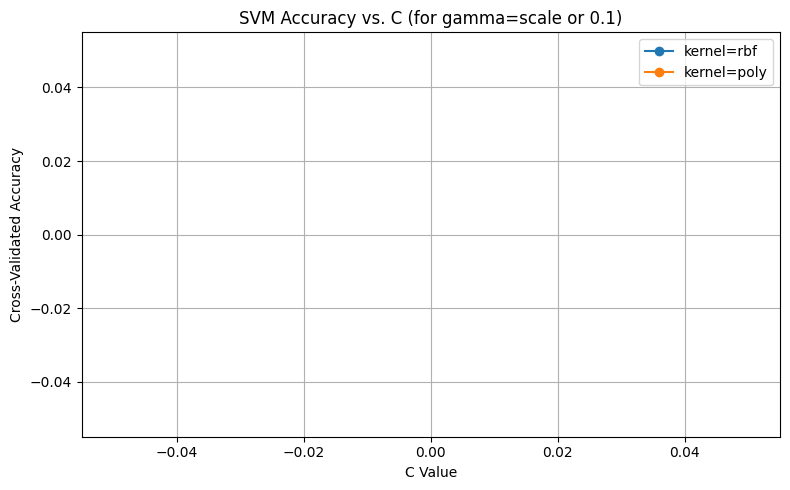

In [10]:
plt.figure(figsize=(8, 5))
for kernel in results_df['param_kernel'].unique():
    subset = results_df[
        (results_df['param_kernel'] == kernel) &
        ((results_df['param_gamma'] == 'scale') | (results_df['param_gamma'] == 0.1))
    ]
    plt.plot(subset['param_C'], subset['mean_test_score'], marker='o', label=f'kernel={kernel}')

plt.title('SVM Accuracy vs. C (for gamma=scale or 0.1)')
plt.xlabel('C Value')
plt.ylabel('Cross-Validated Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Evaluate Best SVM on Test Set

In [11]:

# Your class labels
class_labels = ['Pastry', 'Z_Scratch', 'Stains', 'K_Scatch', 'Dirtiness', 'Bumps', 'Other_Faults']

# Predictions and confusion matrix
y_pred_svm = best_svm.predict(X_test_svm_scaled)
cm_svm = confusion_matrix(y_test_svm, y_pred_svm, normalize='true')
acc_svm = np.trace(cm_svm) / cm_svm.shape[0]
print(f"Tuned SVM Accuracy: {acc_svm * 100:.2f}%")

# Create larger and higher-resolution figure
fig = plt.figure(figsize=(6, 5), dpi=150)
ax = fig.add_subplot(111)

# Add display_labels for proper axis labeling
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_labels)
disp.plot(cmap='Reds', ax=ax, colorbar=True)

plt.title("Confusion Matrix for Hyperparameter 'C' Tuned LinearSVM", fontsize=10)
plt.xticks(fontsize=6, rotation=45)  # rotated for better visibility
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

NameError: name 'best_svm' is not defined